<a href="https://colab.research.google.com/github/DouglasLeite77/mecaniQA-MACAPA/blob/main/baseline_metricas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Leitura e Preparação dos Dados
caminho_arquivo = './datasets/mecaniqa_dataset.xlsx'

# Caso esteja rodando no Colab e o arquivo não esteja mapeado, pede o upload
if not os.path.exists(caminho_arquivo) and not os.path.exists('./mecaniqa_dataset.xlsx'):
    from google.colab import files
    print('Faça o upload da planilha mecaniqa_dataset.xlsx')
    upload = files.upload()
    caminho_arquivo = list(upload.keys())[0]
elif os.path.exists('./mecaniqa_dataset.xlsx'):
    caminho_arquivo = './mecaniqa_dataset.xlsx'

df = pd.read_excel(caminho_arquivo)
df['Data'] = pd.to_datetime(df['Data'])
df = df.sort_values('Data').set_index('Data')

# Isola a primeira coluna numérica como nossa série alvo
serie_manutencoes = df.select_dtypes('number').iloc[:, 0].astype(float)

print('Dados carregados com sucesso! Total de registros:', len(serie_manutencoes))

Faça o upload da planilha mecaniqa_dataset.xlsx


Saving mecaniqa_dataset (2).xlsx to mecaniqa_dataset (2).xlsx
Dados carregados com sucesso! Total de registros: 731


In [2]:
# 2. Funções de Baseline com Proteção contra Vazamento (Shift)

def modelo_naive(serie):
    """A previsão de hoje é o valor exato de ontem."""
    return serie.shift(1)

def modelo_media_movel(serie, janela=7):
    """A previsão de hoje é a média dos 'n' dias anteriores."""
    return serie.shift(1).rolling(window=janela).mean()

previsao_naive = modelo_naive(serie_manutencoes)
previsao_mm7 = modelo_media_movel(serie_manutencoes, janela=7)

print('Previsões de baseline calculadas e protegidas.')

Previsões de baseline calculadas e protegidas.


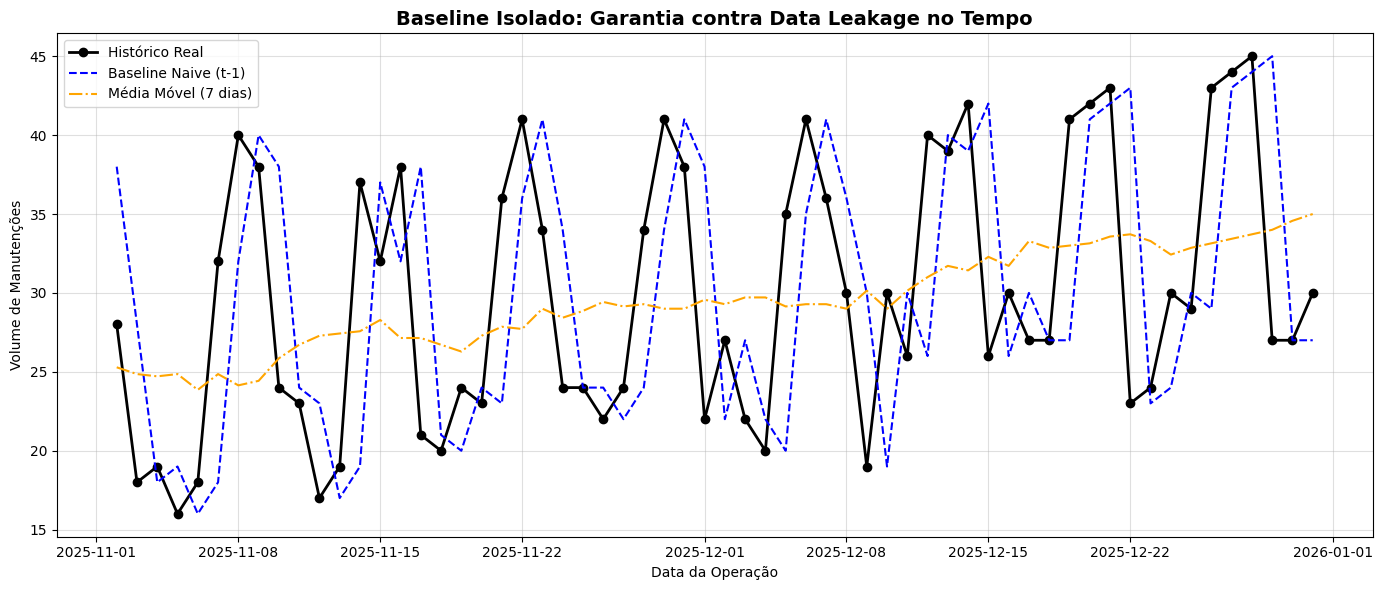

In [3]:
# 3. Validação Visual para QA (Critério de Aceite)
plt.figure(figsize=(14, 6))

# Filtro de zoom nos últimos 60 dias para visualizar o deslocamento temporal
dias_zoom = -60

plt.plot(serie_manutencoes[dias_zoom:], label='Histórico Real', color='black', linewidth=2, marker='o')
plt.plot(previsao_naive[dias_zoom:], label='Baseline Naive (t-1)', color='blue', linestyle='--')
plt.plot(previsao_mm7[dias_zoom:], label='Média Móvel (7 dias)', color='orange', linestyle='-.')

plt.title('Baseline Isolado: Garantia contra Data Leakage no Tempo', fontsize=14, fontweight='bold')
plt.xlabel('Data da Operação')
plt.ylabel('Volume de Manutenções')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()